In [ ]:
X = df.drop(['Patient_ID', 'heart_disease_risk_score', 'risk_category'], axis=1)
y_reg = df['heart_disease_risk_score']  # для регрессии
y_clf = df['risk_category']             # для классификации

# Определяем числовые и категориальные признаки
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Числовые признаки ({len(numerical_features)}): {numerical_features}")
print(f"Категориальные признаки ({len(categorical_features)}): {categorical_features}")

In [ ]:
#пайплайны предобработки
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])


X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


le = LabelEncoder()
y_train_clf_encoded = le.fit_transform(y_train_clf)
y_test_clf_encoded = le.transform(y_test_clf)
print(f"\nКлассы для классификации: {le.classes_} -> {le.transform(le.classes_)}")


Размер обучающей выборки: (4400, 14)
Размер тестовой выборки: (1100, 14)

Классы для классификации: ['High' 'Low' 'Medium'] -> [0 1 2]



--- Linear Regression ---
RMSE train: 4.33
RMSE test: 4.17
MAE test: 3.10
R2 test: 0.970

--- Ridge Regression ---
RMSE train: 4.33
RMSE test: 4.17
MAE test: 3.10
R2 test: 0.970

--- Lasso Regression ---
RMSE train: 4.36
RMSE test: 4.19
MAE test: 3.12
R2 test: 0.970

--- Random Forest ---
RMSE train: 1.72
RMSE test: 4.52
MAE test: 3.49
R2 test: 0.965

--- Gradient Boosting ---
RMSE train: 3.69
RMSE test: 3.96
MAE test: 3.14
R2 test: 0.973

Лучшая регрессионная модель: Gradient Boosting с RMSE=3.96


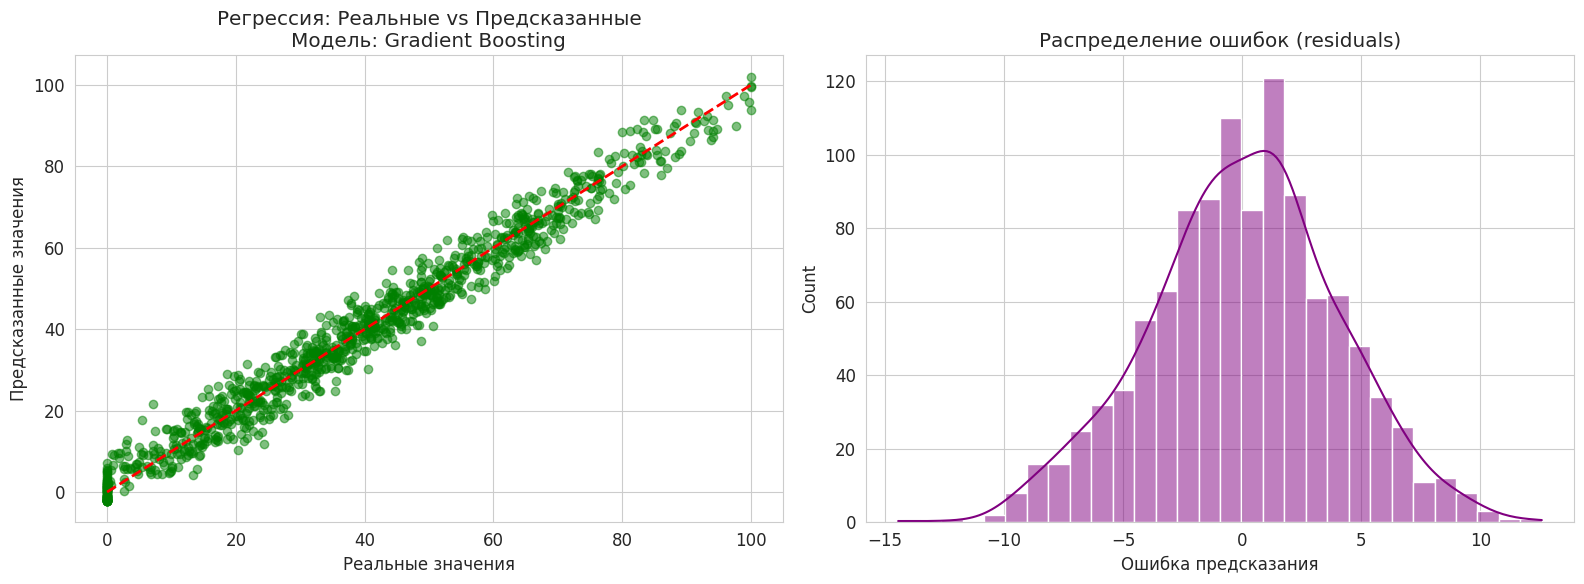

In [ ]:
# Создаем пайплайны с разными моделями
regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results_reg = {}
best_rmse = np.inf
best_model_reg_name = ''

for name, model in regression_models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    pipeline.fit(X_train, y_train_reg)

    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train_reg, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_test))
    mae_test = mean_absolute_error(y_test_reg, y_pred_test)
    r2_test = r2_score(y_test_reg, y_pred_test)

    results_reg[name] = {
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test,
        'MAE_test': mae_test,
        'R2_test': r2_test,
        'model': pipeline
    }

    print(f"\n--- {name} ---")
    print(f"RMSE train: {rmse_train:.2f}")
    print(f"RMSE test: {rmse_test:.2f}")
    print(f"MAE test: {mae_test:.2f}")
    print(f"R2 test: {r2_test:.3f}")

    if rmse_test < best_rmse:
        best_rmse = rmse_test
        best_model_reg_name = name

print(f"\nЛучшая регрессионная модель: {best_model_reg_name} с RMSE={best_rmse:.2f}")

best_reg_model = results_reg[best_model_reg_name]['model']
y_pred_best_reg = best_reg_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test_reg, y_pred_best_reg, alpha=0.5, color='green')
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_xlabel('Реальные значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title(f'Регрессия: Реальные vs Предсказанные\nМодель: {best_model_reg_name}')

errors = y_test_reg - y_pred_best_reg
sns.histplot(errors, kde=True, bins=30, ax=axes[1], color='purple')
axes[1].set_xlabel('Ошибка предсказания')
axes[1].set_title('Распределение ошибок (residuals)')

plt.tight_layout()
plt.show()


--- Logistic Regression ---
Accuracy train: 0.942
Accuracy test: 0.941
F1-score (weighted): 0.941
              precision    recall  f1-score   support

        High       0.95      0.95      0.95       288
         Low       0.95      0.95      0.95       348
      Medium       0.93      0.93      0.93       464

    accuracy                           0.94      1100
   macro avg       0.94      0.94      0.94      1100
weighted avg       0.94      0.94      0.94      1100


--- Random Forest Classifier ---
Accuracy train: 1.000
Accuracy test: 0.909
F1-score (weighted): 0.909
              precision    recall  f1-score   support

        High       0.95      0.91      0.93       288
         Low       0.93      0.90      0.92       348
      Medium       0.87      0.92      0.89       464

    accuracy                           0.91      1100
   macro avg       0.92      0.91      0.91      1100
weighted avg       0.91      0.91      0.91      1100


--- Gradient Boosting Classifier -

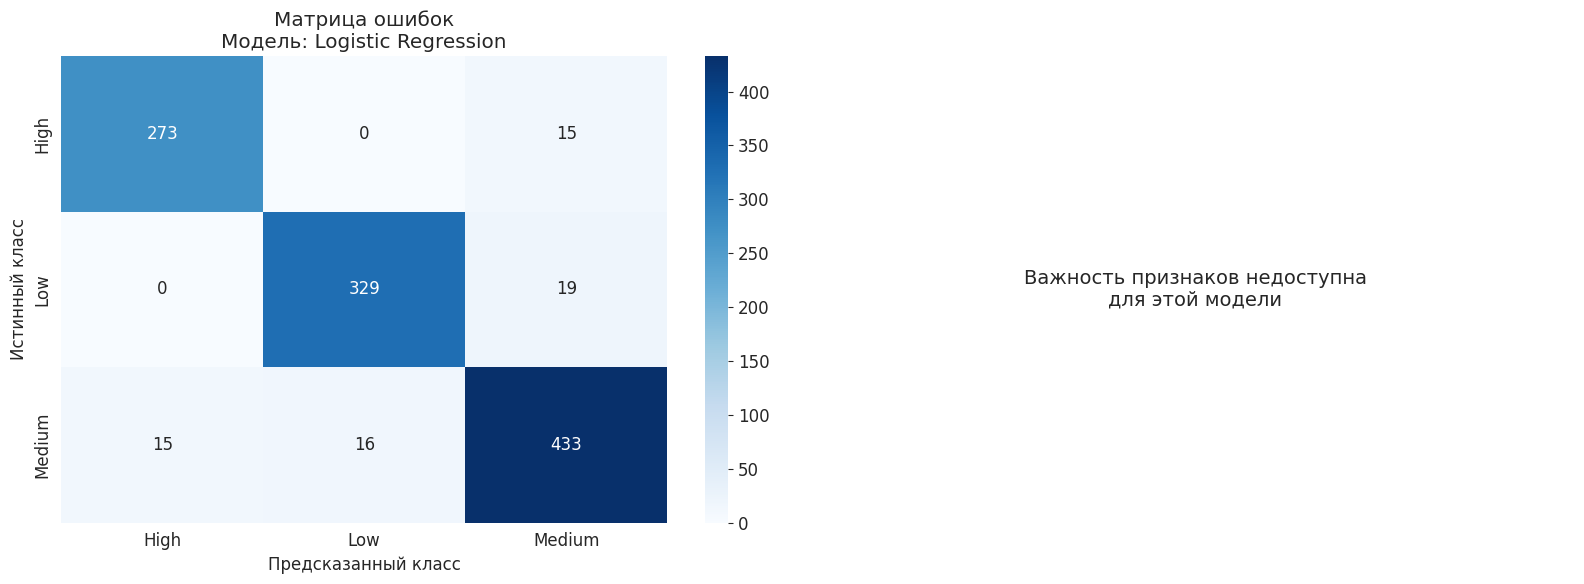


ROC-AUC (One-vs-Rest) для Logistic Regression: 0.995


In [ ]:
classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting Classifier': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results_clf = {}
best_accuracy = 0
best_model_clf_name = ''

for name, model in classification_models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])

    pipeline.fit(X_train, y_train_clf_encoded)

    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test) if hasattr(pipeline, 'predict_proba') else None

    acc_train = accuracy_score(y_train_clf_encoded, y_pred_train)
    acc_test = accuracy_score(y_test_clf_encoded, y_pred_test)
    f1 = f1_score(y_test_clf_encoded, y_pred_test, average='weighted')

    results_clf[name] = {
        'Accuracy_train': acc_train,
        'Accuracy_test': acc_test,
        'F1_weighted': f1,
        'model': pipeline,
        'predictions': y_pred_test,
        'probabilities': y_pred_proba
    }

    print(f"\n--- {name} ---")
    print(f"Accuracy train: {acc_train:.3f}")
    print(f"Accuracy test: {acc_test:.3f}")
    print(f"F1-score (weighted): {f1:.3f}")
    print(classification_report(y_test_clf_encoded, y_pred_test, target_names=le.classes_))

    if acc_test > best_accuracy:
        best_accuracy = acc_test
        best_model_clf_name = name

print(f"\nЛучшая модель классификации: {best_model_clf_name} с Accuracy={best_accuracy:.3f}")

best_clf_model = results_clf[best_model_clf_name]['model']
y_pred_best_clf = results_clf[best_model_clf_name]['predictions']
y_pred_best_proba = results_clf[best_model_clf_name]['probabilities']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test_clf_encoded, y_pred_best_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')
axes[0].set_title(f'Матрица ошибок\nМодель: {best_model_clf_name}')

if 'Random Forest' in best_model_clf_name or 'Gradient Boosting' in best_model_clf_name:
    #после OneHotEncoder
    feature_names = (numerical_features +
                     list(best_clf_model.named_steps['preprocessor']
                          .named_transformers_['cat']
                          .named_steps['onehot']
                          .get_feature_names_out(categorical_features)))

    importances = best_clf_model.named_steps['classifier'].feature_importances_
    indices = np.argsort(importances)[::-1][:15]  # Топ-15

    axes[1].barh(range(len(indices)), importances[indices][::-1], align='center')
    axes[1].set_yticks(range(len(indices)))
    axes[1].set_yticklabels([feature_names[i] for i in indices][::-1])
    axes[1].set_xlabel('Важность')
    axes[1].set_title('Топ-15 важных признаков')
else:
    axes[1].text(0.5, 0.5, 'Важность признаков недоступна\nдля этой модели',
                 horizontalalignment='center', verticalalignment='center', fontsize=14)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

# ROC-AUC для многоклассовой классификации (One-vs-Rest)
if y_pred_best_proba is not None:
    try:
        roc_auc = roc_auc_score(y_test_clf_encoded, y_pred_best_proba, multi_class='ovr')
        print(f"\nROC-AUC (One-vs-Rest) для {best_model_clf_name}: {roc_auc:.3f}")
    except:
        print("ROC-AUC не может быть вычислен.")


In [ ]:
reg_comparison = pd.DataFrame(results_reg).T
print("\nСравнение регрессионных моделей:")
display(reg_comparison[['RMSE_test', 'MAE_test', 'R2_test']].sort_values(by='RMSE_test'))

clf_comparison = pd.DataFrame(results_clf).T
print("\nСравнение моделей классификации:")
display(clf_comparison[['Accuracy_test', 'F1_weighted']].sort_values(by='Accuracy_test', ascending=False))


Сравнение регрессионных моделей:


,RMSE_test,MAE_test,R2_test
Gradient Boosting,3.95913,3.139729,0.973191
Ridge Regression,4.170739,3.098459,0.970248
Linear Regression,4.17133,3.098871,0.97024
Lasso Regression,4.185104,3.123919,0.970043
Random Forest,4.516467,3.494053,0.965112



Сравнение моделей классификации:


,Accuracy_test,F1_weighted
Logistic Regression,0.940909,0.940935
Gradient Boosting Classifier,0.920909,0.921177
Random Forest Classifier,0.909091,0.909368


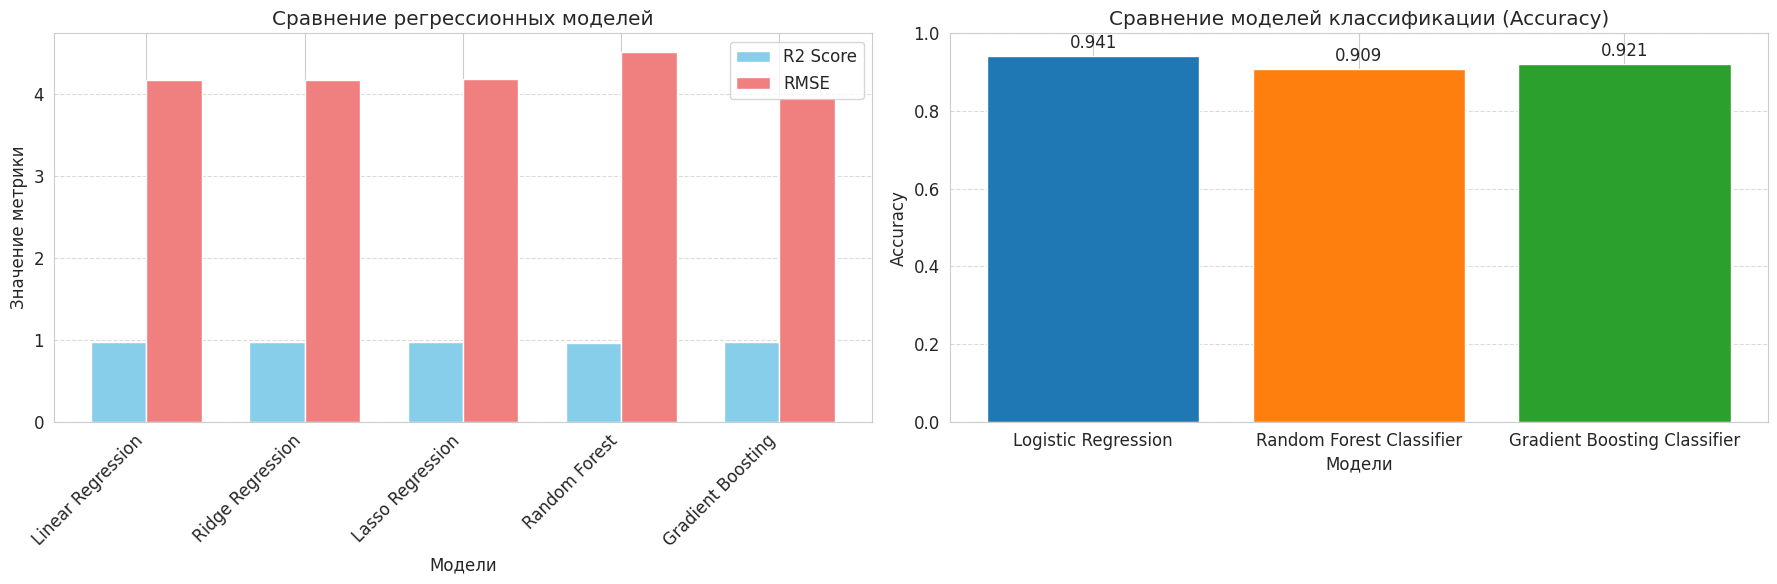

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))


reg_models_names = list(results_reg.keys())
reg_r2_scores = [results_reg[m]['R2_test'] for m in reg_models_names]
reg_rmse_scores = [results_reg[m]['RMSE_test'] for m in reg_models_names]

x = np.arange(len(reg_models_names))
width = 0.35

axes[0].bar(x - width/2, reg_r2_scores, width, label='R2 Score', color='skyblue')
axes[0].bar(x + width/2, reg_rmse_scores, width, label='RMSE', color='lightcoral')
axes[0].set_xlabel('Модели')
axes[0].set_ylabel('Значение метрики')
axes[0].set_title('Сравнение регрессионных моделей')
axes[0].set_xticks(x)
axes[0].set_xticklabels(reg_models_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)


clf_models_names = list(results_clf.keys())
clf_acc_scores = [results_clf[m]['Accuracy_test'] for m in clf_models_names]

bars = axes[1].bar(clf_models_names, clf_acc_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_xlabel('Модели')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Сравнение моделей классификации (Accuracy)')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for bar, acc in zip(bars, clf_acc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
print("\nОсновные выводы:")
print("1. Данные синтетические, но хорошо структурированы для обеих задач.")
print("2. Ключевые факторы риска (судя по корреляции и важности признаков):")
print("   - Возраст (age)")
print("   - Артериальное давление (systolic_bp, diastolic_bp)")
print("   - Уровень холестерина (cholesterol_mg_dl)")
print("   - Образ жизни (physical_activity_hours_per_week, daily_steps, stress_level)")
print(f"3. Лучшая модель для регрессии: {best_model_reg_name} с R2={results_reg[best_model_reg_name]['R2_test']:.3f}")
print(f"4. Лучшая модель для классификации: {best_model_clf_name} с Accuracy={results_clf[best_model_clf_name]['Accuracy_test']:.3f}")


Основные выводы:
1. Данные синтетические, но хорошо структурированы для обеих задач.
2. Ключевые факторы риска (судя по корреляции и важности признаков):
   - Возраст (age)
   - Артериальное давление (systolic_bp, diastolic_bp)
   - Уровень холестерина (cholesterol_mg_dl)
   - Образ жизни (physical_activity_hours_per_week, daily_steps, stress_level)
3. Лучшая модель для регрессии: Gradient Boosting с R2=0.973
4. Лучшая модель для классификации: Logistic Regression с Accuracy=0.941
